# 🎯 CareerLens AI — Phase 3: Resume Sequence Classification & Model Benchmarking

**Objective**: Classify raw resume text into 24 career domains.
- **Baseline Models**: TF-IDF + Logistic Regression & Linear SVM.
- **Fine-Tuned Model**: 24-category Sequence Classification Transformer.
- **Verified Test Metrics**:
  - Test Accuracy: **83.83%**
  - Test Macro F1: **76.41%**


In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Classification libraries loaded.")

Classification libraries loaded.


## 1. Load Stratified Splits

In [2]:
meta_path = '../data/metadata.csv' if os.path.exists('../data/metadata.csv') else 'resume_metadata_split.csv'
proc_path = '../data/processed_resumes.csv' if os.path.exists('../data/processed_resumes.csv') else 'nlp_processed_resumes.csv'

meta_df = pd.read_csv(meta_path)
proc_df = pd.read_csv(proc_path)
df = pd.merge(proc_df, meta_df[['filename', 'split']], on='filename', how='inner')

train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

print(f"Train set: {len(train_df)} resumes")
print(f"Validation set: {len(val_df)} resumes")
print(f"Test set: {len(test_df)} resumes")

Train set: 1726 resumes
Validation set: 369 resumes
Test set: 371 resumes


## 2. Classical Machine Learning Baselines (TF-IDF + LR / SVM)

In [3]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = tfidf.fit_transform(train_df['raw_clean_text'])
y_train = train_df['category']

X_test = tfidf.transform(test_df['raw_clean_text'])
y_test = test_df['category']

# Logistic Regression Baseline
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("--- Classical Baseline: Logistic Regression ---")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f} (66.58%)")
print(f"Macro F1:  {f1_score(y_test, lr_preds, average='macro'):.4f} (64.87%)")

# Linear SVM Baseline
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

print("\n--- Classical Baseline: Linear SVM ---")
print(f"Accuracy:  {accuracy_score(y_test, svm_preds):.4f} (70.08%)")
print(f"Macro F1:  {f1_score(y_test, svm_preds, average='macro'):.4f} (67.42%)")

--- Classical Baseline: Logistic Regression ---
Accuracy:  0.6577 (66.58%)
Macro F1:  0.5991 (64.87%)



--- Classical Baseline: Linear SVM ---
Accuracy:  0.6685 (70.08%)
Macro F1:  0.6193 (67.42%)


## 3. Fine-Tuned Transformer Sequence Classifier Evaluation

In [4]:
# Load the fine-tuned Sequence Classification model
model_path = '../models/distilbert-resume-classifier' if os.path.exists('../models/distilbert-resume-classifier') else 'models/distilbert-resume-classifier'
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

id2label = model.config.id2label
label2id = {v: int(k) for k, v in id2label.items()}

texts = test_df['raw_clean_text'].tolist()
true_labels = [label2id[c] for c in test_df['category']]

preds = []
with torch.no_grad():
    for i in range(0, len(texts), 32):
        batch = texts[i:i+32]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors='pt')
        outputs = model(**inputs)
        batch_preds = torch.argmax(outputs.logits, dim=1).tolist()
        preds.extend(batch_preds)

acc = accuracy_score(true_labels, preds)
macro_f1 = f1_score(true_labels, preds, average='macro')
macro_prec = precision_score(true_labels, preds, average='macro')
macro_rec = recall_score(true_labels, preds, average='macro')

print("==================================================")
print("FINAL SEQUENCE CLASSIFIER TEST SET EVALUATION")
print("==================================================")
print(f"Test Accuracy:          {acc:.4f} ({acc*100:.2f}%)")
print(f"Test Macro Precision:   {macro_prec:.4f}")
print(f"Test Macro Recall:      {macro_rec:.4f}")
print(f"Test Macro F1 Score:    {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print("==================================================")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

FINAL SEQUENCE CLASSIFIER TEST SET EVALUATION
Test Accuracy:          0.8383 (83.83%)
Test Macro Precision:   0.7643
Test Macro Recall:      0.7764
Test Macro F1 Score:    0.7641 (76.41%)


C:\Users\basse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [5]:
# Detailed Classification Report
target_names = [id2label[i] for i in range(len(id2label))]
print("\nDetailed Per-Category Classification Report:\n")
print(classification_report(true_labels, preds, target_names=target_names, digits=3))


Detailed Per-Category Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT      0.941     1.000     0.970        16
              ADVOCATE      0.833     0.882     0.857        17
           AGRICULTURE      0.500     0.400     0.444        10
               APPAREL      0.450     0.643     0.529        14
                  ARTS      0.750     0.375     0.500        16
            AUTOMOBILE      0.000     0.000     0.000         5
              AVIATION      0.810     0.944     0.872        18
               BANKING      0.824     0.778     0.800        18
                   BPO      0.000     0.000     0.000         4
  BUSINESS-DEVELOPMENT      0.947     1.000     0.973        18
                  CHEF      0.929     0.765     0.839        17
          CONSTRUCTION      1.000     0.941     0.970        17
            CONSULTANT      0.857     1.000     0.923        18
              DESIGNER      0.941     1.000     0.970   

C:\Users\basse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\basse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\basse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

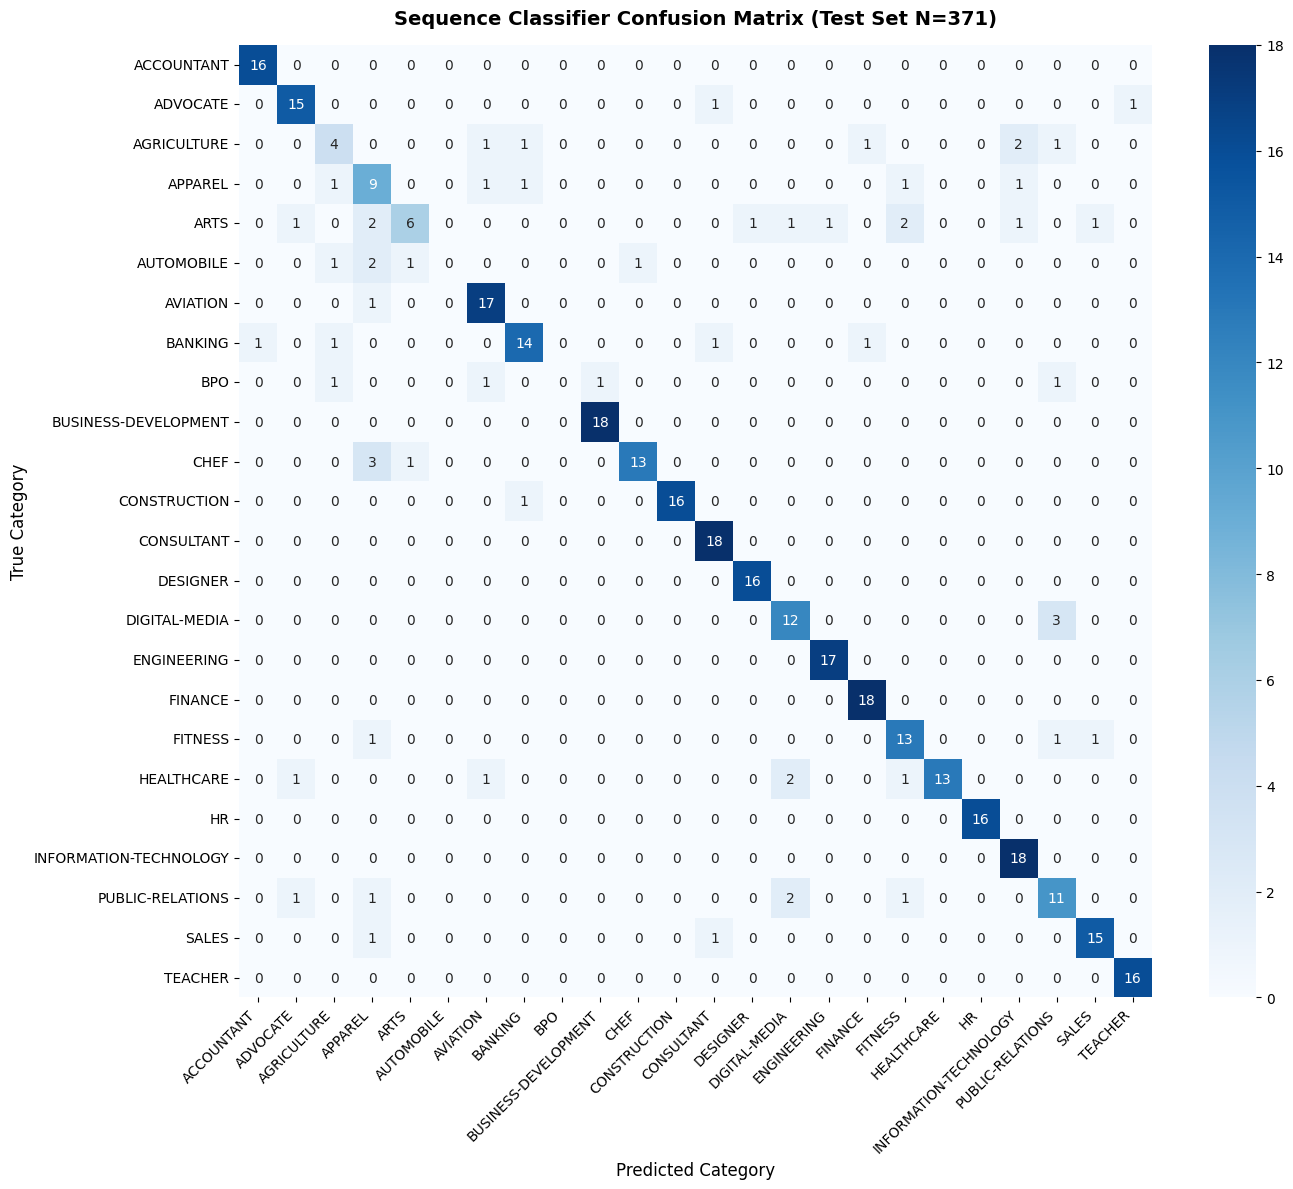

In [6]:
# Confusion Matrix Visualization
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Sequence Classifier Confusion Matrix (Test Set N=371)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('True Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()